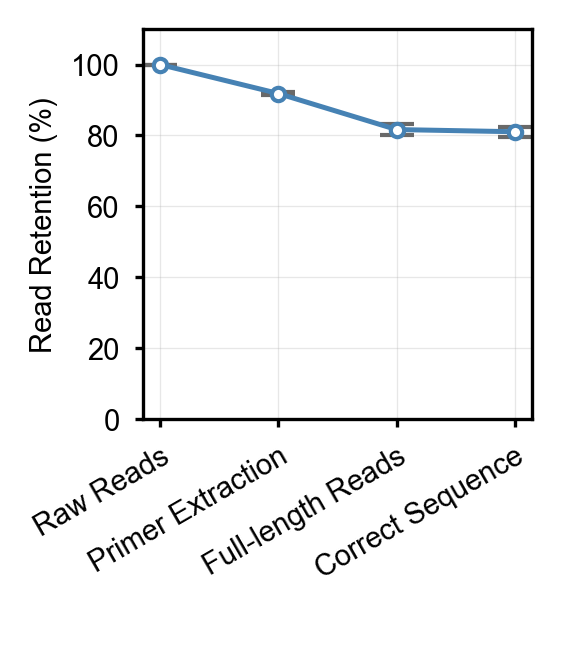

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================== 数据读取 ==================
df = pd.read_excel("capture_error_rata_20250423.xlsx", sheet_name="Sheet4")
steps = df.iloc[:, 0]
raw_reads = df.iloc[0, 1:]
retention = df.iloc[:, 1:] / raw_reads.values
mean_retention = retention.mean(axis=1) * 100
std_retention  = retention.std(axis=1)  * 100

# ================== 字体与图形参数 ==================
cm = 1 / 2.54
plt.rcParams["font.family"]   = "Arial"
plt.rcParams["font.size"]     = 7
plt.rcParams["pdf.fonttype"]  = 42
plt.rcParams["svg.fonttype"]  = "path"   # 转曲线避免重叠

# ================== Axes 精确 3.3 cm × 3.3 cm ==================
AX_W, AX_H = 3.3 * cm, 3.3 * cm
LEFT, RIGHT, TOP, BOTTOM = 0.40, 0.1, 0.10, 0.6   # inch，底部留足空间防截断

FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# ================== 绘制折线 + 误差棒 ==================
ax.errorbar(
    steps, mean_retention, yerr=std_retention,
    fmt='o-', color='steelblue',
    ecolor='dimgray', elinewidth=1.3, capsize=4.0, capthick=1.0,
    markersize=3.2, linewidth=1.2,
    markerfacecolor='white', markeredgecolor='steelblue'
)

# ================== 坐标轴与样式 ==================
ax.set_ylim(0, 110)
ax.set_xlabel(" ", fontsize=7, labelpad=2)
ax.set_ylabel("Read Retention (%)", fontsize=7, labelpad=3)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps, rotation=30, ha='right', rotation_mode='anchor')
ax.tick_params(axis='both', labelsize=7, length=2)
ax.grid(alpha=0.3, linewidth=0.3)

# ================== 保存 ==================
# PDF：可编辑文本（出版友好）
fig.savefig("average_retention_final.pdf", format="pdf",
            bbox_inches=None, pad_inches=0)

# SVG：文字转曲线，绝不重叠
fig.savefig("average_retention_final.svg", format="svg",
            bbox_inches=None, pad_inches=0)

plt.show()


✅ 已完成标准化，每个脑区的 Malat1 均为 1,000,000。


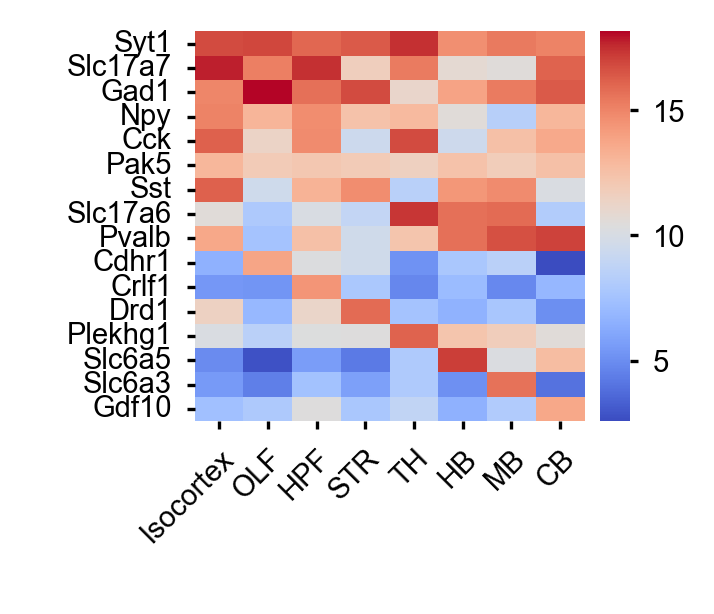

In [117]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 参数区（按需修改）
# =========================
xlsx_path  = "17_1_e.xlsx"
sheet_name = 0
do_log2    = True
drop_gene  = "Malat1"       # 若要去掉某基因
norm_size = 1000000
cmap_name  = "coolwarm"
vmin, vmax = None, None     # 比如设 (0,20)；不确定就 None

# ✅ 直接指定要显示的“基因”（行）和“脑区”（列）
genes   = ["Syt1","Slc17a7","Gad1","Npy",
           "Cck","Pak5","Sst","Slc17a6","Pvalb","Cdhr1","Crlf1","Drd1","Plekhg1","Slc6a5","Slc6a3","Gdf10"]
regions = ["Isocortex","OLF","HPF","STR","TH","HB","MB","CB"]

# =========================
# 尺寸与字体（Axes=3.3 cm）
# =========================
cm = 1/2.54
AX_W = 3.3 * cm
AX_H = 3.3 * cm

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"]   = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "path"  # 防止 SVG 字符重叠

# 画布边距与色条（英寸）
LEFT, RIGHT, BOTTOM, TOP = 0.50, 0.20, 0.40, 0.10
CBAR_W, CBAR_PAD = 0.10, 0.05
FIG_W = LEFT + AX_W + CBAR_PAD + CBAR_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

# =========================
# 读取 & 取子集（行=基因，列=脑区）
# =========================
df = pd.read_excel(xlsx_path, sheet_name=sheet_name, index_col=0)
# 取出每个脑区对应的 Malat1 表达量
malat1_values = df["Malat1"].replace(0, np.nan)  # 防止除以 0

# 按列标准化，使 Malat1 = 1,000,000
df_norm = df.div(malat1_values, axis=0) * norm_size
# 确保 Malat1 行为精确 1,000,000
df_norm["Malat1"] = norm_size
df = df_norm

print("✅ 已完成标准化，每个脑区的 Malat1 均为 1,000,000。")


# 去掉基因（可选）
if drop_gene is not None and drop_gene in df.index:
    df = df.drop(index=drop_gene)

# ——严格取子集（不存在就报错）：——
df_sub = df.loc[regions,genes]

# 如希望“有则取、无则忽略”，用下面两行替换上一行：
# df_sub = df.reindex(index=genes, columns=regions)
# df_sub = df_sub.dropna(how="all").dropna(axis=1, how="all")

# 对数变换（可选）
if do_log2:
    df_sub = np.log2(df_sub + 1)

# =========================
# 转置后作图：X=基因，Y=脑区
# =========================
mat_df = df_sub.T   # 行=脑区，列=基因（横轴是基因）

# =========================
# 绘图（固定 Axes=3.3 cm）
# =========================
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)

ax = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])
cax = fig.add_axes([(LEFT+AX_W+CBAR_PAD)/FIG_W, BOTTOM/FIG_H, CBAR_W/FIG_W, AX_H/FIG_H])

sns.heatmap(
    mat_df,
    ax=ax,
    cbar=True,
    cbar_ax=cax,
    cmap=cmap_name,
    vmin=vmin, vmax=vmax,
    xticklabels=True, yticklabels=True,
    linewidths=0
)

# 样式
ax.set_xlabel(" ", fontsize=7, labelpad=2)
ax.set_ylabel("  ", fontsize=7, labelpad=2)
ax.tick_params(axis='both', labelsize=7, length=2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
cax.tick_params(labelsize=7, length=2)

# 保存（不裁剪，保持尺寸一致）
fig.savefig("heatmap_axes_3p3cm_subset.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("heatmap_axes_3p3cm_subset.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


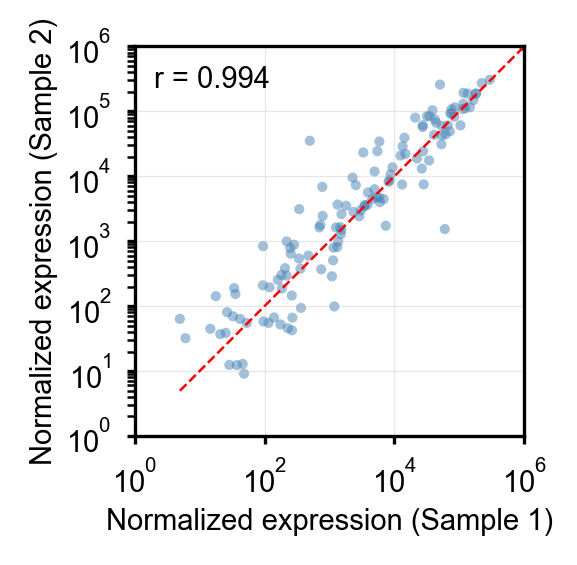

In [119]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 参数 ==========
file1 = "17_1_e.xlsx"
file2 = "17_2_e.xlsx"
sheet = 0
target_gene = "Malat1"

# ========== 标准化函数 ==========
def normalize_by_malat1(df, gene="Malat1"):
    """每行是脑区，每列是基因"""
    df = df.apply(pd.to_numeric, errors="coerce")
    if gene not in df.columns:
        raise KeyError(f"未找到列 {gene}")
    malat = df[gene].replace(0, np.nan)
    df_norm = df.div(malat, axis=0) * 1_000_000
    df_norm[gene] = 1_000_000
    return df_norm

# ========== 读取并标准化 ==========
df1 = normalize_by_malat1(pd.read_excel(file1, sheet_name=sheet, index_col=0))
df2 = normalize_by_malat1(pd.read_excel(file2, sheet_name=sheet, index_col=0))

# 对齐基因
common_genes = df1.columns.intersection(df2.columns)
df1 = df1[common_genes]
df2 = df2[common_genes]

# 展平为向量
vals1 = df1.stack()
vals2 = df2.stack()
df_compare = pd.DataFrame({"Sample1": vals1, "Sample2": vals2}).dropna()

# ========== 计算总体相关性 ==========
r = df_compare["Sample1"].corr(df_compare["Sample2"], method="pearson")

# ========== 绘制散点图（Axes = 3.3 cm × 3.3 cm） ==========
cm = 1 / 2.54
AX_W, AX_H = 3.3 * cm, 3.3 * cm

# 图像边距（inch）
LEFT, RIGHT, BOTTOM, TOP = 0.4, 0.2, 0.4, 0.2
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "path"

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# 绘制点
ax.scatter(df_compare["Sample1"], df_compare["Sample2"],
           s=6, alpha=0.5, color="steelblue", edgecolor="none")

# y=x 参考线
lims = [
    min(df_compare.min().min(), df_compare.min().min()),
    max(df_compare.max().max(), df_compare.max().max())
]
ax.plot(lims, lims, "r--", lw=0.6)

# 坐标样式
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 1_000_000)
ax.set_ylim(1, 1_000_000)
ax.set_xlabel("Normalized expression (Sample 1)", fontsize=7, labelpad=2)
ax.set_ylabel("Normalized expression (Sample 2)", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)

# 标注相关系数
ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=7)

# 保存
fig.savefig("malat1_scatter_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("malat1_scatter_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


✅ 每列总值标准化后的 Pearson 相关系数: r = 0.8486


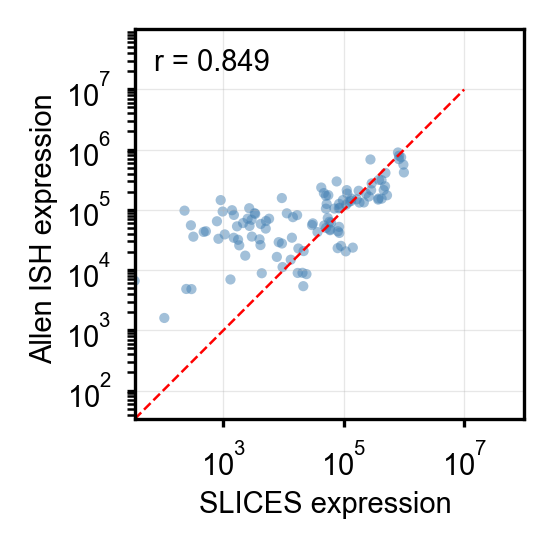

In [183]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 参数
# =========================
file1 = "17_1_e.xlsx"
file2 = "20g_expression_table.csv"
sheet = 0
target_sum = 1_000_000   # 每列标准化后的总值（类似 TPM/CPM 的思路）

# =========================
# 读取与预处理
# =========================
df1 = pd.read_excel(file1, sheet_name=sheet, index_col=0)
df2 = pd.read_csv(file2, index_col=0)

# 确保为数值
df1 = df1.apply(pd.to_numeric, errors="coerce")
df2 = df2.apply(pd.to_numeric, errors="coerce")

# =========================
# 按列总值标准化：每列和 -> target_sum
# =========================
def col_total_normalize(df, target=1_000_000):
    col_sums = df.sum(axis=0)
    # 避免除以 0：为 0 的列保持为 NaN，后面 dropna 处理
    col_sums = col_sums.replace(0, np.nan)
    return df.div(col_sums, axis=1) * target

df1_norm = col_total_normalize(df1, target_sum)
df2_norm = col_total_normalize(df2, target_sum)

# =========================
# 对齐公共基因（列）
# =========================
common_genes = df1_norm.columns.intersection(df2_norm.columns)
if len(common_genes) == 0:
    raise ValueError("两个数据集没有共同的基因列，请检查列名是否一致。")
df1c = df1_norm[common_genes]
df2c = df2_norm[common_genes]

# 展平为一维向量并对齐索引
vals1 = df1c.stack()
vals2 = df2c.stack()
df_compare = pd.DataFrame({"Sample1": vals1, "Sample2": vals2}).dropna()

# =========================
# 计算总体相关性
# =========================
r = df_compare["Sample1"].corr(df_compare["Sample2"], method="pearson")
print(f"✅ 每列总值标准化后的 Pearson 相关系数: r = {r:.4f}")

# =========================
# 绘制散点图（Axes = 3.3 cm × 3.3 cm）
# =========================
cm = 1 / 2.54
AX_W, AX_H = 3.3*cm, 3.3*cm

# 手动边距（inch）
LEFT, RIGHT, BOTTOM, TOP = 0.40, 0.10, 0.40, 0.10
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams["font.family"]  = "Arial"
plt.rcParams["font.size"]    = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "path"   # SVG 文本转曲线，避免字符重叠

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# 散点
ax.scatter(df_compare["Sample1"], df_compare["Sample2"],
           s=6, alpha=0.5, color="steelblue", edgecolor="none")

# y=x 参考线（用数据范围自动适配）
min_pos = max(1e-6, df_compare.min().min())  # 防 log(<=0)
max_pos = max(df_compare.max().max()*10, target_sum)  # 上界至少覆盖 target_sum
ax.plot([min_pos, max_pos], [min_pos, max_pos], "r--", lw=0.6)

# 对数坐标更直观
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(min_pos, max_pos*10)
ax.set_ylim(min_pos, max_pos*10)

ax.set_xlabel("SLICES expression ", fontsize=7, labelpad=2)
ax.set_ylabel("Allen ISH expression ", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)

# 标注相关系数
ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=7)

# 保存（固定画布，不裁剪）
fig.savefig("scatter_coltotal_norm_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("scatter_coltotal_norm_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


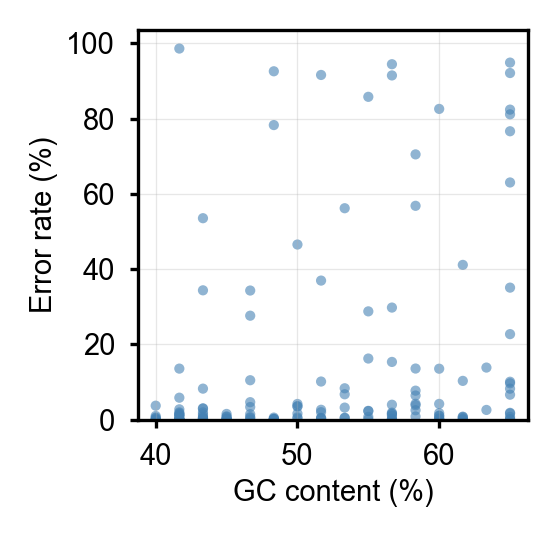

In [140]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 读取数据
# =========================
xlsx_path = "umi_info.xlsx"

# sheet1：三列（基因序号、探针序号、GC比例）
# 若没有列名也没关系，这里统一改名为 ['gene_id','probe_id','gc_ratio']
info = pd.read_excel(xlsx_path, sheet_name=0, header=0)
if info.shape[1] < 3:
    raise ValueError("Sheet1 至少需要三列：基因序号、探针序号、GC比例。")
info = info.iloc[:, :3].copy()
info.columns = ["gene_id", "probe_id", "gc_ratio"]

# sheet2：探针对样本的 counts（行=探针顺序与sheet1一致，列=样本）
counts = pd.read_excel(xlsx_path, sheet_name=1, header=0)
# sheet3：探针对样本的错误 counts（行=探针顺序与sheet1一致，列=样本）
errors = pd.read_excel(xlsx_path, sheet_name=2, header=0)

# =========================
# 清洗与对齐
# =========================
# 若 counts / errors 第一列其实是probe_id，可尝试去掉它，保持与 info 行数一致
def maybe_drop_first_id_col(df_like, expected_rows):
    if df_like.shape[1] >= 2 and df_like.shape[0] == expected_rows:
        # 如果第一列与 info.probe_id“像是”相同，去掉它
        first_col = df_like.columns[0]
        # 简单启发式：如果第一列全是字符串或与info长度相等，且数量级很像ID，就去掉
        if df_like[first_col].dtype == object or str(first_col).lower() in {"id","probe","probe_id"}:
            # 检查是否去掉后列数仍>=1
            if df_like.shape[1] - 1 >= 1:
                return df_like.iloc[:, 1:].copy()
    return df_like

counts = maybe_drop_first_id_col(counts, info.shape[0])
errors = maybe_drop_first_id_col(errors, info.shape[0])

# 确保为数值
counts = counts.apply(pd.to_numeric, errors="coerce")
errors = errors.apply(pd.to_numeric, errors="coerce")

# 行数必须与 sheet1 相同（行顺序对齐）
if counts.shape[0] != info.shape[0] or errors.shape[0] != info.shape[0]:
    raise ValueError("Sheet2/Sheet3 的行数应与 Sheet1 的探针数一致，并保持相同顺序。")

# =========================
# 计算每个探针的总counts、错误counts、错误率
# =========================
total_counts = counts.sum(axis=1)        # 每个探针 across 样本的总counts
error_counts = errors.sum(axis=1)        # 每个探针 across 样本的错误counts
with np.errstate(divide='ignore', invalid='ignore'):
    error_rate = (error_counts /(error_counts + total_counts)).replace([np.inf, -np.inf], np.nan)

# 组装结果表
df_res = info.copy()
df_res["total_counts"] = total_counts.values
df_res["error_counts"] = error_counts.values
df_res["error_rate"]   = error_rate.values  # 0~1

# 处理 GC 比例：若原来是 0~1，小数→百分数；若原来是 0~100，保持不变
gc_raw = df_res["gc_ratio"].astype(float)
if gc_raw.max() <= 1.01:   # 容忍微小浮动
    gc_pct = gc_raw * 100.0
else:
    gc_pct = gc_raw
df_res["gc_pct"] = gc_pct
df_res["error_pct"] = df_res["error_rate"] * 100.0

# 去掉无效点（总counts为0 或 错误率NaN）
df_plot = df_res.dropna(subset=["error_pct", "gc_pct"]).copy()
df_plot = df_plot[df_plot["total_counts"] > 0]

# =========================
# 绘图（Axes = 3.3 cm × 3.3 cm）
# =========================
cm = 1/2.54
AX_W, AX_H = 3.3*cm, 3.3*cm

# 手动边距（inch）
LEFT, RIGHT, BOTTOM, TOP = 0.45, 0.20, 0.50, 0.20
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams["font.family"]  = "Arial"
plt.rcParams["font.size"]    = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "path"   # 避免 SVG 字符重叠

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# 散点
ax.scatter(df_plot["gc_pct"], df_plot["error_pct"],
           s=6, alpha=0.6, color="steelblue", edgecolor="none")

# 轴标签与范围
ax.set_xlabel("GC content (%)", fontsize=7, labelpad=2)
ax.set_ylabel("Error rate (%)", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)

# x轴范围按数据稍微留白
x_min, x_max = df_plot["gc_pct"].min(), df_plot["gc_pct"].max()
pad = max(1.0, (x_max - x_min) * 0.05)
ax.set_xlim(x_min - pad, x_max + pad)

# y轴下限从0开始，上限按数据稍微留白
y_max = df_plot["error_pct"].max() if not df_plot["error_pct"].empty else 1.0
ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)

# 可选：简单的线性拟合线（去掉注释即可）
# m, b = np.polyfit(df_plot["gc_pct"], df_plot["error_pct"], 1)
# xs = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
# ax.plot(xs, m*xs + b, color="darkorange", lw=0.8)

# 保存
fig.savefig("gc_vs_error_scatter_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("gc_vs_error_scatter_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_49984\4119103521.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


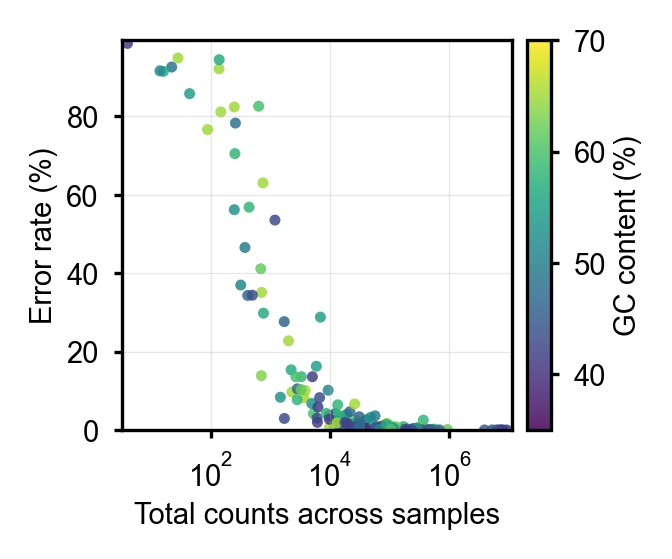

In [146]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# =========================
# 读取数据
# =========================
xlsx_path = "umi_info.xlsx"

info   = pd.read_excel(xlsx_path, sheet_name=0, header=0).iloc[:, :3]
info.columns = ["gene_id", "probe_id", "gc_ratio"]

counts = pd.read_excel(xlsx_path, sheet_name=1, header=0)
errors = pd.read_excel(xlsx_path, sheet_name=2, header=0)

def maybe_drop_first_id_col(df_like, expected_rows):
    if df_like.shape[1] >= 2 and df_like.shape[0] == expected_rows:
        first_col = df_like.columns[0]
        if df_like[first_col].dtype == object or str(first_col).lower() in {"id","probe","probe_id"}:
            return df_like.iloc[:, 1:].copy()
    return df_like

counts = maybe_drop_first_id_col(counts, info.shape[0]).apply(pd.to_numeric, errors="coerce")
errors = maybe_drop_first_id_col(errors, info.shape[0]).apply(pd.to_numeric, errors="coerce")

assert counts.shape[0] == info.shape[0] and errors.shape[0] == info.shape[0]

# =========================
# 计算每个探针的总 counts、错误率
# =========================
probe_total = counts.sum(axis=1)
error_total = errors.sum(axis=1)
error_rate  = (error_total /(error_total+ probe_total)).replace([np.inf, -np.inf], np.nan)

# =========================
# 基因内标准化：每个基因的探针平均 counts = 1
# =========================
df_metric = info.copy()
df_metric["probe_total"] = probe_total.values
gene_means = df_metric.groupby("gene_id")["probe_total"].transform(lambda s: s.replace(0, np.nan).mean())
df_metric["gene_norm"] = df_metric["probe_total"] / gene_means

gc_raw = df_metric["gc_ratio"].astype(float)
df_metric["gc_pct"] = gc_raw * 100.0 if gc_raw.max() <= 1.01 else gc_raw
df_metric["error_pct"] = error_rate.values * 100.0
df_plot = df_metric.replace([np.inf, -np.inf], np.nan).dropna(subset=["gc_pct","gene_norm","error_pct"])
df_plot = df_plot[df_plot["probe_total"] > 0]

# =========================
# 绘图：x=counts, y=error rate, color=GC%
# =========================
cm2inch = 1/2.54
AX_W, AX_H = 3.3*cm2inch, 3.3*cm2inch
LEFT, RIGHT, BOTTOM, TOP = 0.45, 0.25, 0.50, 0.20
CBAR_W, CBAR_PAD = 0.08, 0.05
FIG_W = LEFT + AX_W + CBAR_PAD + CBAR_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "path"
})

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])
cax = fig.add_axes([(LEFT+AX_W+CBAR_PAD)/FIG_W, BOTTOM/FIG_H, CBAR_W/FIG_W, AX_H/FIG_H])

# 颜色范围限定在 35–70%
norm = Normalize(vmin=35, vmax=70)
cmap = cm.get_cmap("viridis")

sc = ax.scatter(
    df_plot["probe_total"], df_plot["error_pct"],
    c=np.clip(df_plot["gc_pct"], 35, 70), cmap=cmap, norm=norm,
    s=7, alpha=0.85, edgecolor="none"
)

ax.set_xlabel("Total counts across samples", fontsize=7, labelpad=2)
ax.set_ylabel("Error rate (%)", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)

# 对数 X 轴方便显示范围大
ax.set_xscale("log")

# X 轴范围
x_min, x_max = df_plot["probe_total"].min(), df_plot["probe_total"].max()
ax.set_xlim(x_min*0.8, x_max*1.2)

# Y 轴范围
y_max = np.nanpercentile(df_plot["error_pct"], 99)
ax.set_ylim(0, y_max*1.05)

# 色条
cb = plt.colorbar(sc, cax=cax)
cb.set_label("GC content (%)", fontsize=7, labelpad=2)
cb.ax.tick_params(labelsize=7, length=2)

# 保存
fig.savefig("counts_vs_error_coloredByGC_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("counts_vs_error_coloredByGC_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_51240\1582711015.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


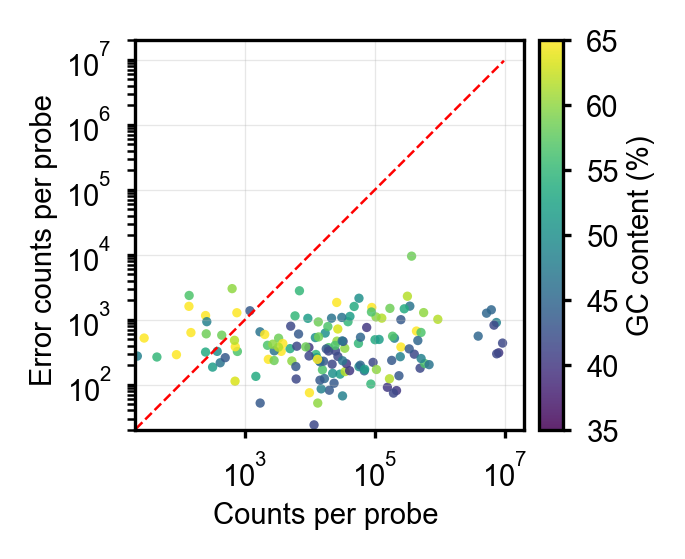

In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# =========================
# 读取数据
# =========================
xlsx_path = "umi_info.xlsx"

# Sheet1: 三列（基因序号、探针序号、GC比例）
info = pd.read_excel(xlsx_path, sheet_name=0, header=0).iloc[:, :3].copy()
info.columns = ["gene_id", "probe_id", "gc_ratio"]

# Sheet2: 行=探针、列=样本，总 counts
counts = pd.read_excel(xlsx_path, sheet_name=1, header=0)
# Sheet3: 行=探针、列=样本，错误 counts
errors = pd.read_excel(xlsx_path, sheet_name=2, header=0)

def maybe_drop_first_id_col(df_like, expected_rows):
    """若首列是ID，则去掉；要求行数与Sheet1一致"""
    if df_like.shape[1] >= 2 and df_like.shape[0] == expected_rows:
        first_col = df_like.columns[0]
        if df_like[first_col].dtype == object or str(first_col).lower() in {"id", "probe", "probe_id"}:
            return df_like.iloc[:, 1:].copy()
    return df_like

counts = maybe_drop_first_id_col(counts, info.shape[0]).apply(pd.to_numeric, errors="coerce")
errors = maybe_drop_first_id_col(errors, info.shape[0]).apply(pd.to_numeric, errors="coerce")

assert counts.shape[0] == info.shape[0] and errors.shape[0] == info.shape[0], "三张表的探针行数需一致且顺序对应。"

# =========================
# 计算每个探针的总 counts 与 错误 counts
# =========================
probe_total = counts.sum(axis=1)   # X
error_total = errors.sum(axis=1)   # Y

# 组装绘图数据
df_plot = info.copy()
# GC：若为 0–1 则转为百分比
gc_raw = df_plot["gc_ratio"].astype(float)
df_plot["gc_pct"] = gc_raw * 100.0 if gc_raw.max() <= 1.01 else gc_raw
df_plot["probe_total"] = probe_total.values
df_plot["error_total"] = error_total.values

# 去掉无效点
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=["gc_pct", "probe_total", "error_total"])
df_plot = df_plot[(df_plot["probe_total"] > 0) | (df_plot["error_total"] > 0)]

# =========================
# 绘图（Axes = 3.3 cm × 3.3 cm，右侧窄色条）
# =========================
cm2inch = 1/2.54
AX_W, AX_H = 3.3*cm2inch, 3.3*cm2inch
LEFT, RIGHT, BOTTOM, TOP = 0.45, 0.35, 0.40, 0.10  # inch
CBAR_W, CBAR_PAD = 0.08, 0.05
FIG_W = LEFT + AX_W + CBAR_PAD + CBAR_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "path"   # 转曲线避免 SVG 字体重叠
})

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])
cax = fig.add_axes([(LEFT+AX_W+CBAR_PAD)/FIG_W, BOTTOM/FIG_H, CBAR_W/FIG_W, AX_H/FIG_H])

# 颜色范围限定在 35–70%
norm = Normalize(vmin=35, vmax=65)
cmap = cm.get_cmap("viridis")

sc = ax.scatter(
    df_plot["probe_total"], df_plot["error_total"],
    c=np.clip(df_plot["gc_pct"], 35, 65), cmap=cmap, norm=norm,
    s=5, alpha=0.85, edgecolor="none"
)

ax.set_xlabel("Counts per probe ", fontsize=7, labelpad=2)
ax.set_ylabel("Error counts per probe ", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], "r--", lw=0.6)

# 建议用对数坐标（counts/错误counts跨度大时更清晰）
ax.set_xscale("log")
ax.set_yscale("log")

# 合理的范围
x_min = max(1, df_plot["probe_total"].min())
x_max = df_plot["probe_total"].max()
y_min = max(1, df_plot["error_total"].replace(0, np.nan).min(skipna=True) or 1)
y_max = df_plot["error_total"].max()
ax.set_xlim(20, 20000000)
ax.set_ylim(20, 20000000)

# 色条
cb = plt.colorbar(sc, cax=cax)
cb.set_label("GC content (%)", fontsize=7, labelpad=2)
cb.ax.tick_params(labelsize=7, length=2)

# 保存
fig.savefig("counts_vs_errorCounts_coloredByGC_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("counts_vs_errorCounts_coloredByGC_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


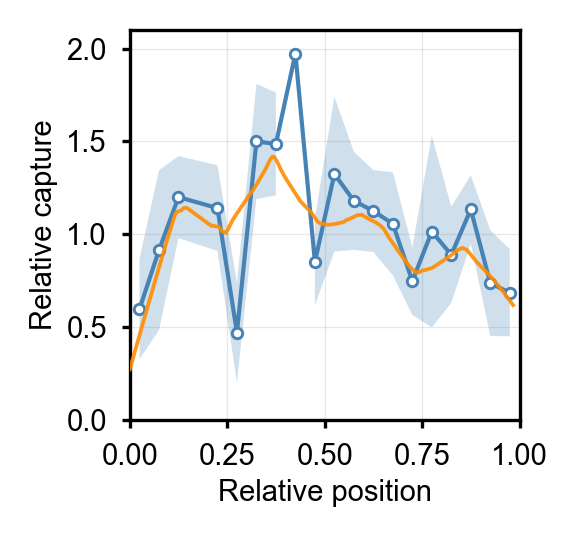

In [180]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import math

# ========= 路径与表结构 =========
meta_path    = "probe_stage.xlsx"  # Sheet1: gene, probe_id, pos_on_rna, rna_len
counts_path  = "umi_info.xlsx"     # counts：与 meta 的探针行顺序对齐（本例用第2个sheet）
sheet_meta   = 0
sheet_counts = 1

# ========= 读取元信息，算相对位置 =========
meta = pd.read_excel(meta_path, sheet_name=sheet_meta, header=0)
meta = meta.iloc[:, :4].copy()
meta.columns = ["gene", "probe_id", "pos_on_rna", "rna_len"]
meta["rel_pos"] = meta["pos_on_rna"].astype(float) / meta["rna_len"].replace(0, np.nan).astype(float)

# ========= 读取 counts 并转数值 =========
counts = pd.read_excel(counts_path, sheet_name=sheet_counts, header=0)
def maybe_drop_first_id_col(df_like, expected_rows):
    if df_like.shape[1] >= 2 and df_like.shape[0] == expected_rows:
        first_col = df_like.columns[0]
        if df_like[first_col].dtype == object or str(first_col).lower() in {"id","probe","probe_id","probeid"}:
            return df_like.iloc[:, 1:].copy()
    return df_like
counts = maybe_drop_first_id_col(counts, meta.shape[0])
counts = counts.apply(pd.to_numeric, errors="coerce")
assert counts.shape[0] == meta.shape[0], "umi_info 与 probe_stage 的探针行数需一致且顺序对应。"

# ========= 按“样本×基因”标准化：同一基因在同一样本内，探针均值=1 =========
genes = meta["gene"].astype(str).values
norm_counts = counts.copy()
for c in counts.columns:
    col = counts[c].values
    # 每基因在该样本内的探针均值
    gene_means = pd.Series(col, index=genes).groupby(genes).transform(lambda s: np.nan if s.mean()==0 else s.mean()).values
    with np.errstate(divide='ignore', invalid='ignore'):
        norm_counts[c] = col / gene_means

# ========= 汇总到“每探针的样本均值与SEM” =========
probe_mean = norm_counts.mean(axis=1)
probe_sd   = norm_counts.std(axis=1, ddof=1)
n_samples  = norm_counts.shape[1]
probe_sem  = probe_sd / math.sqrt(n_samples) if n_samples > 1 else probe_sd*0

df = meta[["rel_pos"]].copy()
df["mean_rel_capture"] = probe_mean.values
df["sem"] = probe_sem.values
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["rel_pos", "mean_rel_capture"])

# ========= 分箱统计：均值 ± SEM（主文主体元素） =========
n_bins = 20
bins = np.linspace(0, 1, n_bins+1)
labels = (bins[:-1] + bins[1:]) / 2   # bin 中心
df["bin"] = pd.cut(df["rel_pos"], bins, include_lowest=True, labels=labels)

bin_stats = (
    df.groupby("bin", observed=True)["mean_rel_capture"]
      .agg(["mean", "std", "count"])
      .reset_index()
      .rename(columns={"bin":"pos"})
)
bin_stats["sem"] = bin_stats["std"] / np.sqrt(bin_stats["count"].clip(lower=1))
bin_stats = bin_stats.dropna(subset=["pos", "mean"])

# ========= LOWESS 平滑（辅线，细且不喧宾夺主） =========
# 用所有探针的 (rel_pos, mean_rel_capture) 做LOWESS
xy = df[["rel_pos", "mean_rel_capture"]].dropna().to_numpy()
xy = xy[np.argsort(xy[:,0])]
sm = lowess(endog=xy[:,1], exog=xy[:,0], frac=0.25, it=1, return_sorted=True)  # frac可调：0.2~0.4

# ========= 绘图（Axes=3.3cm×3.3cm, Arial 7pt） =========
cm = 1/2.54
AX_W, AX_H = 3.3*cm, 3.3*cm
LEFT, RIGHT, BOTTOM, TOP = 0.45, 0.20, 0.50, 0.20
FIG_W, FIG_H = LEFT + AX_W + RIGHT, BOTTOM + AX_H + TOP

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "path"
})

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# ——主体：分箱均值线 + SEM 阴影——
ax.plot(bin_stats["pos"].astype(float), bin_stats["mean"], '-o',
        lw=1.0, ms=2.5, color='steelblue',
        markerfacecolor='white', markeredgewidth=0.7, zorder=3)
ax.fill_between(bin_stats["pos"].astype(float),
                bin_stats["mean"] - bin_stats["sem"],
                bin_stats["mean"] + bin_stats["sem"],
                color='steelblue', alpha=0.25, linewidth=0, zorder=2)

# ——辅线：LOWESS 平滑曲线——
ax.plot(sm[:,0], sm[:,1], color='darkorange', lw=0.9, alpha=0.9, zorder=4)

# 轴样式
ax.set_xlabel("Relative position", fontsize=7, labelpad=2)
ax.set_ylabel("Relative capture", fontsize=7, labelpad=2)
ax.set_xlim(0, 1)

# y 轴范围：用分位数抑制极端点
y_lo = np.nanpercentile(df["mean_rel_capture"], 1)
y_hi = np.nanpercentile(df["mean_rel_capture"], 99)
#ax.set_ylim(max(0, y_lo*0.95), y_hi*1.05 if np.isfinite(y_hi) else None)
ax.set_ylim(0, 2.1 if np.isfinite(y_hi) else None)

ax.grid(alpha=0.3, lw=0.3)
ax.tick_params(length=2)

fig.savefig("MAIN_relpos_trend_binned_mean_LOWESS_3p3cm.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("MAIN_relpos_trend_binned_mean_LOWESS_3p3cm.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()
